<a href="https://colab.research.google.com/github/johnjoseph004/AI-ML-internship/blob/main/day_5_test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import zipfile
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

zip_file_path = '/content/archive (21).zip'
extract_root_dir = '/content/extracted_data'

os.makedirs(extract_root_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_root_dir)

print(f"Files extracted to: {extract_root_dir}")

data_dir = os.path.join(extract_root_dir, 'brain_tumor_dataset')

IMG_HEIGHT = 128
IMG_WIDTH = 128

features = []
labels = []

class_names = sorted(os.listdir(data_dir))
class_to_label = {name: i for i, name in enumerate(class_names)}
print(f"Detected classes: {class_names}")
print(f"Class to label mapping: {class_to_label}")

for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path).resize((IMG_WIDTH, IMG_HEIGHT)).convert('RGB')
                img_array = np.array(img).flatten()
                features.append(img_array)
                labels.append(class_to_label[class_name])
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")

X = np.array(features)
y = np.array(labels)

print(f"Total images loaded: {len(X)}")
print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Files extracted to: /content/extracted_data
Detected classes: ['no', 'yes']
Class to label mapping: {'no': 0, 'yes': 1}
Total images loaded: 253
Feature matrix shape: (253, 49152)
Label vector shape: (253,)
X_train shape: (202, 49152)
X_test shape: (51, 49152)
y_train shape: (202,)
y_test shape: (51,)


In [4]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='linear', random_state=42)
print("\nTraining SVM model...")
svm_model.fit(X_train_scaled, y_train)
print("SVM model training complete.")

y_pred = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Training SVM model...
SVM model training complete.

Model Accuracy: 0.7843

Classification Report:
              precision    recall  f1-score   support

          no       0.71      0.75      0.73        20
         yes       0.83      0.81      0.82        31

    accuracy                           0.78        51
   macro avg       0.77      0.78      0.78        51
weighted avg       0.79      0.78      0.79        51


Confusion Matrix:
[[15  5]
 [ 6 25]]


Saving brain tumour yes.jpeg to brain tumour yes.jpeg
Uploaded file: brain tumour yes.jpeg

Prediction for the uploaded image: yes


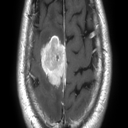

In [5]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  uploaded_img_path = fn

print(f"Uploaded file: {uploaded_img_path}")

try:
    img = Image.open(uploaded_img_path).resize((IMG_WIDTH, IMG_HEIGHT)).convert('RGB')
    img_array = np.array(img).flatten()

    img_array_scaled = scaler.transform(img_array.reshape(1, -1))

    prediction_numeric = svm_model.predict(img_array_scaled)
    prediction_label = class_names[prediction_numeric[0]]

    print(f"\nPrediction for the uploaded image: {prediction_label}")

    from IPython.display import display
    display(img)

except Exception as e:
    print(f"Error processing uploaded image: {e}")
    print("Please ensure you uploaded a valid image file.")